# Tutorial: MLP para una regresion aeroespacial con Keras

## Objetivo

En este cuaderno construiremos un modelo MLP para estimar la **distancia de carrera de despegue** de una aeronave ligera a partir de:

- masa de despegue
- superficie alar
- empuje disponible
- configuracion aerodinamica
- viento en pista
- pendiente de pista
- altitud de presion y temperatura

El dataset sera **sintetico**, pero generado con una fisica simplificada razonable. Esto permite tener un ejemplo mas cercano a ingenieria aeroespacial sin depender de ficheros externos.

## Flujo del tutorial

1. Generar un dataset fisicamente inspirado.
2. Explorar las variables mas influyentes.
3. Entrenar una linea base lineal.
4. Entrenar una MLP con Keras.
5. Comparar metricas y analizar curvas de aprendizaje.
6. Hacer un pequeno estudio paramétrico de sensibilidad.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import keras
from keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras version:", keras.__version__)
print("Backend activo:", keras.backend.backend())


Keras version: 3.10.0
Backend activo: tensorflow


## 1. Dataset sintetico de prestaciones de despegue

La idea es aproximar la distancia de carrera mediante:

- velocidad de sustentacion minima y velocidad de lift-off
- resistencia aerodinamica media durante la carrera
- reduccion de la carga normal por la sustentacion
- efecto de viento en cara y pendiente de pista
- efecto de altitud y temperatura a traves de la densidad del aire

No es un modelo de certificacion, pero si una aproximacion coherente para un ejercicio de regresion.


In [2]:
def air_density_from_conditions(pressure_altitude_ft, temperature_c):
    g = 9.80665
    R = 287.05
    T0 = 288.15
    P0 = 101325.0
    lapse = 0.0065

    h_m = pressure_altitude_ft * 0.3048
    t_std = T0 - lapse * h_m
    pressure = P0 * (t_std / T0) ** (g / (R * lapse))
    temperature_k = temperature_c + 273.15
    rho = pressure / (R * temperature_k)
    return np.clip(rho, 0.65, 1.25)


def generate_takeoff_dataset(n_samples=5000, seed=SEED):
    rng = np.random.default_rng(seed)

    mass_kg = rng.uniform(900.0, 3500.0, n_samples)
    wing_area_m2 = rng.uniform(12.0, 32.0, n_samples)
    thrust_n = rng.uniform(1800.0, 14000.0, n_samples)
    cl_max_to = rng.uniform(1.4, 2.5, n_samples)
    cd_to = rng.uniform(0.030, 0.085, n_samples)
    rolling_mu = rng.uniform(0.020, 0.045, n_samples)
    headwind_mps = rng.uniform(-4.0, 12.0, n_samples)
    runway_slope_pct = rng.uniform(-1.5, 2.0, n_samples)
    pressure_altitude_ft = rng.uniform(0.0, 10000.0, n_samples)
    temperature_c = rng.uniform(-5.0, 38.0, n_samples)

    rho = air_density_from_conditions(pressure_altitude_ft, temperature_c)

    g = 9.81
    weight_n = mass_kg * g
    v_stall = np.sqrt((2.0 * weight_n) / (rho * wing_area_m2 * cl_max_to))
    v_liftoff = 1.15 * v_stall

    cl_avg = 0.75 * cl_max_to
    v_avg = 0.70 * v_liftoff
    q_avg = 0.5 * rho * v_avg**2

    lift_avg = np.minimum(q_avg * wing_area_m2 * cl_avg, 0.85 * weight_n)
    cd_avg = cd_to + 0.045 * cl_avg**2
    drag_avg = q_avg * wing_area_m2 * cd_avg

    effective_speed = np.clip(v_liftoff - 0.60 * headwind_mps, 8.0, None)
    slope_force = weight_n * runway_slope_pct / 100.0
    net_force = thrust_n - drag_avg - rolling_mu * (weight_n - lift_avg) - slope_force
    acceleration = np.clip(net_force / mass_kg, 0.8, 4.5)

    ground_roll_m = effective_speed**2 / (2.0 * acceleration)
    rotation_margin_m = rng.uniform(20.0, 70.0, n_samples)
    noise_m = rng.normal(0.0, 12.0 + 0.04 * ground_roll_m, n_samples)
    takeoff_distance_m = np.clip(ground_roll_m + rotation_margin_m + noise_m, 120.0, None)

    feature_names = [
        "mass_kg",
        "wing_area_m2",
        "thrust_n",
        "cl_max_to",
        "cd_to",
        "rolling_mu",
        "headwind_mps",
        "runway_slope_pct",
        "pressure_altitude_ft",
        "temperature_c",
    ]

    X = np.column_stack([
        mass_kg,
        wing_area_m2,
        thrust_n,
        cl_max_to,
        cd_to,
        rolling_mu,
        headwind_mps,
        runway_slope_pct,
        pressure_altitude_ft,
        temperature_c,
    ]).astype("float32")

    y = takeoff_distance_m.astype("float32")

    return X, y, feature_names


X, y, feature_names = generate_takeoff_dataset()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Rango de distancia de despegue [m]:", round(float(y.min()), 2), "->", round(float(y.max()), 2))


X shape: (5000, 10)
y shape: (5000,)
Rango de distancia de despegue [m]: 120.0 -> 3436.55


In [3]:
# Vista rapida de algunas muestras
idx = np.arange(5)
for i in idx:
    sample = {name: round(float(value), 3) for name, value in zip(feature_names, X[i])}
    sample["takeoff_distance_m"] = round(float(y[i]), 3)
    print(sample)


{'mass_kg': 2912.286, 'wing_area_m2': 16.363, 'thrust_n': 10592.887, 'cl_max_to': 1.782, 'cd_to': 0.071, 'rolling_mu': 0.044, 'headwind_mps': 1.554, 'runway_slope_pct': -1.018, 'pressure_altitude_ft': 2914.198, 'temperature_c': 24.506, 'takeoff_distance_m': 479.002}
{'mass_kg': 2041.084, 'wing_area_m2': 25.259, 'thrust_n': 10477.101, 'cl_max_to': 1.513, 'cd_to': 0.085, 'rolling_mu': 0.045, 'headwind_mps': 2.736, 'runway_slope_pct': -0.991, 'pressure_altitude_ft': 1208.365, 'temperature_c': 27.489, 'takeoff_distance_m': 170.468}
{'mass_kg': 3132.354, 'wing_area_m2': 27.337, 'thrust_n': 4272.879, 'cl_max_to': 1.732, 'cd_to': 0.032, 'rolling_mu': 0.041, 'headwind_mps': 11.755, 'runway_slope_pct': -0.431, 'pressure_altitude_ft': 1073.729, 'temperature_c': 8.348, 'takeoff_distance_m': 682.25}
{'mass_kg': 2713.157, 'wing_area_m2': 15.333, 'thrust_n': 2247.196, 'cl_max_to': 2.287, 'cd_to': 0.043, 'rolling_mu': 0.031, 'headwind_mps': -2.653, 'runway_slope_pct': 1.183, 'pressure_altitude_ft': 9

## 2. Analisis exploratorio


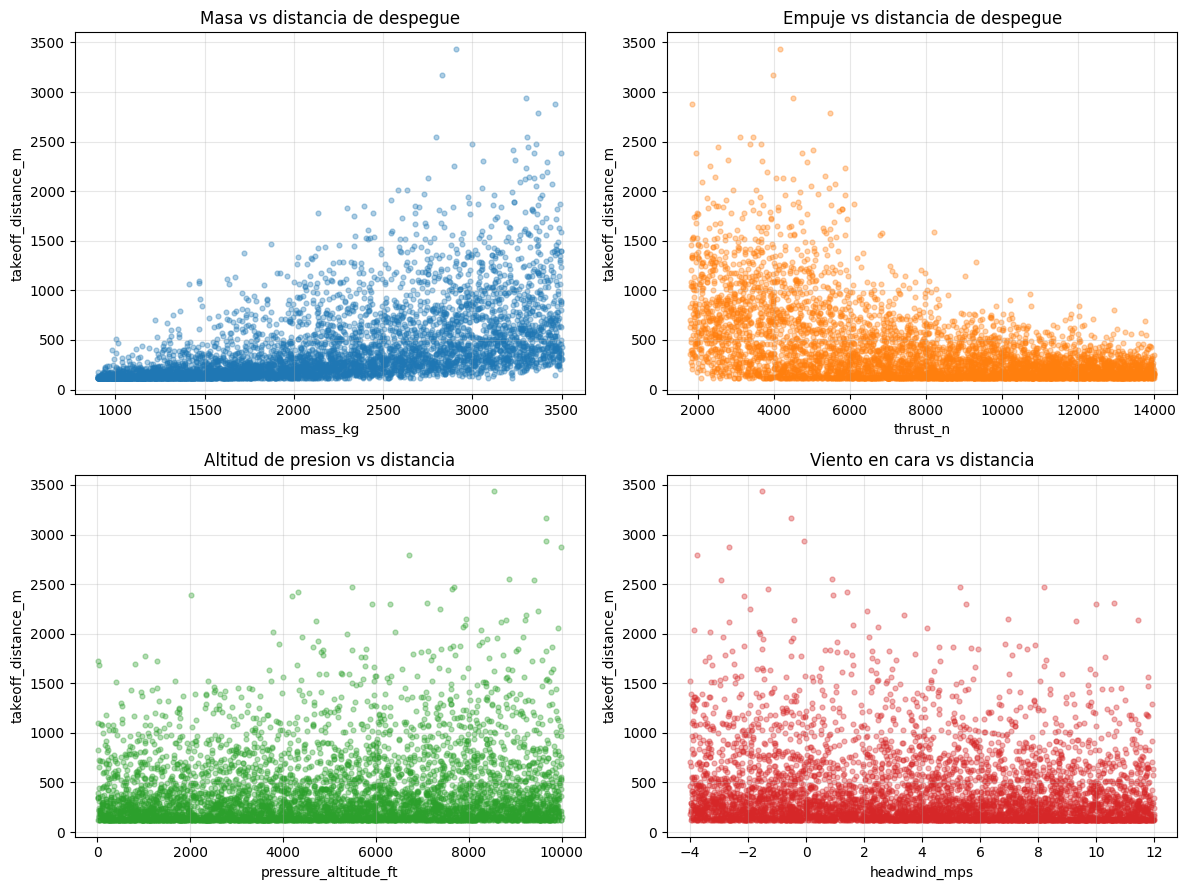

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

mass = X[:, feature_names.index("mass_kg")]
thrust = X[:, feature_names.index("thrust_n")]
pressure_altitude = X[:, feature_names.index("pressure_altitude_ft")]
headwind = X[:, feature_names.index("headwind_mps")]

axes[0, 0].scatter(mass, y, alpha=0.35, s=12)
axes[0, 0].set_title("Masa vs distancia de despegue")
axes[0, 0].set_xlabel("mass_kg")
axes[0, 0].set_ylabel("takeoff_distance_m")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(thrust, y, alpha=0.35, s=12, color="#ff7f0e")
axes[0, 1].set_title("Empuje vs distancia de despegue")
axes[0, 1].set_xlabel("thrust_n")
axes[0, 1].set_ylabel("takeoff_distance_m")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(pressure_altitude, y, alpha=0.35, s=12, color="#2ca02c")
axes[1, 0].set_title("Altitud de presion vs distancia")
axes[1, 0].set_xlabel("pressure_altitude_ft")
axes[1, 0].set_ylabel("takeoff_distance_m")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(headwind, y, alpha=0.35, s=12, color="#d62728")
axes[1, 1].set_title("Viento en cara vs distancia")
axes[1, 1].set_xlabel("headwind_mps")
axes[1, 1].set_ylabel("takeoff_distance_m")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Separacion train/test y escalado


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, y_train.shape)
print("Test :", X_test_scaled.shape, y_test.shape)


Train: (4000, 10) (4000,)
Test : (1000, 10) (1000,)


## 4. Linea base: regresion lineal

Antes de entrenar la MLP, conviene comprobar si una aproximacion lineal ya es suficiente. En este problema esperamos que no lo sea, porque la relacion entre variables y distancia de despegue es claramente no lineal.


In [6]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
metrics_linear = regression_metrics(y_test, y_pred_linear)

print("Linea base lineal:")
for key, value in metrics_linear.items():
    print(f"{key}: {value:.4f}")


Linea base lineal:
MAE: 146.2876
RMSE: 200.9051
R2: 0.7032


## 5. MLP con Keras

Usaremos una red densa sencilla. No incluyo regularizacion explicita porque el dataset es grande y el problema no exige una arquitectura agresiva. Aun asi, usaremos `EarlyStopping` para no entrenar mas de lo necesario.


In [7]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 344056.6562 - mae: 424.9720 - val_loss: 290502.3125 - val_mae: 393.4739
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 337200.3438 - mae: 417.8165 - val_loss: 274068.8750 - val_mae: 376.8523
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 312562.4688 - mae: 394.8638 - val_loss: 229206.2500 - val_mae: 333.4273
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 253053.2188 - mae: 340.1663 - val_loss: 153280.0938 - val_mae: 253.8130
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 162959.0469 - mae: 249.2008 - val_loss: 76365.7891 - val_mae: 161.1476
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 81659.3750 - mae: 160.4219 - val_loss: 35411.2031 - val_mae: 110.9425
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42453.1953 - mae: 119.6909 - val_loss: 24052.6387 - val_mae: 100.2495
Epoch 8/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31281.7793 - mae: 109.7617 -

## 6. Curvas de aprendizaje


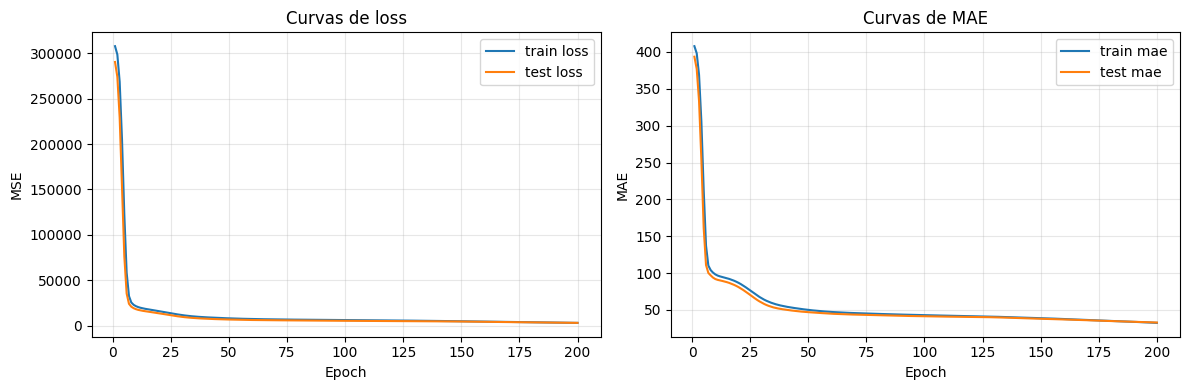

In [9]:
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, hist["loss"], label="train loss")
axes[0].plot(epochs, hist["val_loss"], label="test loss")
axes[0].set_title("Curvas de loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, hist["mae"], label="train mae")
axes[1].plot(epochs, hist["val_mae"], label="test mae")
axes[1].set_title("Curvas de MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluacion comparativa


In [10]:
y_pred_mlp = model.predict(X_test_scaled, verbose=0).squeeze()
metrics_mlp = regression_metrics(y_test, y_pred_mlp)

print("MLP:")
for key, value in metrics_mlp.items():
    print(f"{key}: {value:.4f}")

rows = [
    {"Modelo": "Regresion lineal", **metrics_linear},
    {"Modelo": "MLP Keras", **metrics_mlp},
]

for row in rows:
    print(row)


MLP:
MAE: 33.0050
RMSE: 55.0865
R2: 0.9777
{'Modelo': 'Regresion lineal', 'MAE': 146.28758239746094, 'RMSE': np.float64(200.9050809773113), 'R2': 0.7031838893890381}
{'Modelo': 'MLP Keras', 'MAE': 33.00499725341797, 'RMSE': np.float64(55.0864554870342), 'R2': 0.9776850938796997}


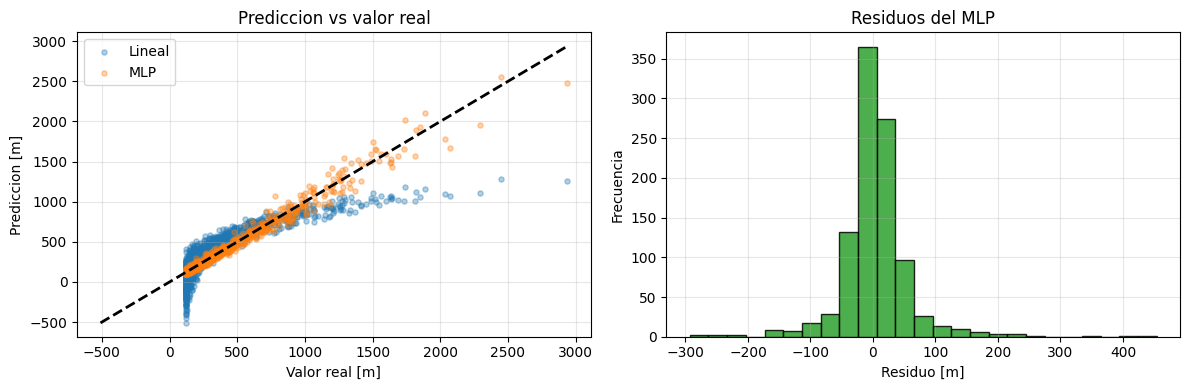

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_linear, alpha=0.35, s=14, label="Lineal")
axes[0].scatter(y_test, y_pred_mlp, alpha=0.35, s=14, label="MLP")
min_val = min(y_test.min(), y_pred_linear.min(), y_pred_mlp.min())
max_val = max(y_test.max(), y_pred_linear.max(), y_pred_mlp.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "k--", linewidth=2)
axes[0].set_title("Prediccion vs valor real")
axes[0].set_xlabel("Valor real [m]")
axes[0].set_ylabel("Prediccion [m]")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

residuals = y_test - y_pred_mlp
axes[1].hist(residuals, bins=25, color="#2ca02c", alpha=0.85, edgecolor="black")
axes[1].set_title("Residuos del MLP")
axes[1].set_xlabel("Residuo [m]")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Estudio parametrico sencillo


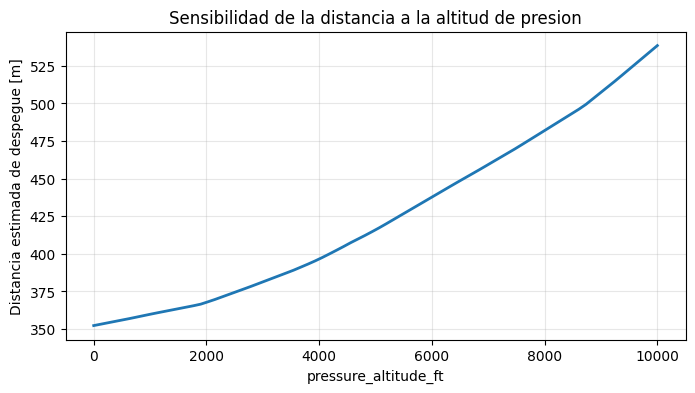

In [12]:
reference_case = {
    "mass_kg": 1800.0,
    "wing_area_m2": 16.5,
    "thrust_n": 4500.0,
    "cl_max_to": 1.9,
    "cd_to": 0.050,
    "rolling_mu": 0.028,
    "headwind_mps": 2.0,
    "runway_slope_pct": 0.0,
    "pressure_altitude_ft": 0.0,
    "temperature_c": 15.0,
}


def case_to_array(case_dict):
    return np.array([[case_dict[name] for name in feature_names]], dtype="float32")


altitudes = np.linspace(0.0, 10000.0, 80)
predicted_takeoff_distance = []

for alt in altitudes:
    case = reference_case.copy()
    case["pressure_altitude_ft"] = alt
    case["temperature_c"] = 25.0
    x_case = scaler.transform(case_to_array(case))
    pred = model.predict(x_case, verbose=0).item()
    predicted_takeoff_distance.append(pred)

plt.figure(figsize=(8, 4))
plt.plot(altitudes, predicted_takeoff_distance, linewidth=2)
plt.title("Sensibilidad de la distancia a la altitud de presion")
plt.xlabel("pressure_altitude_ft")
plt.ylabel("Distancia estimada de despegue [m]")
plt.grid(True, alpha=0.3)
plt.show()


## Conclusiones

- La regresion lineal sirve como referencia rapida, pero no captura bien las no linealidades del problema.
- La MLP aprende mejor la relacion entre masa, empuje, aerodinamica y atmosfera.
- El ejemplo no sustituye a un calculo de prestaciones certificado, pero si muestra muy bien cuando una red neuronal aporta valor en un problema de ingenieria.
